In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [2]:
from joblib import Parallel, delayed

In [3]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [4]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

In [5]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

#df['phase'] = df['phase'].replace({'M': 'G2'})

# Separate features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # exclude phase and age
y = df['age']  # target is now age

feature_names = X.columns.tolist()
X = X.to_numpy()
y = y.to_numpy()

# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949)

In [6]:
def DecisionTreeReg(X,Y,X1):
    tree = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 ).fit(X,Y)
    return tree.predict(X1)

In [7]:
J1 = 0
J2 = 1
B = 5000
fit_func = DecisionTreeReg

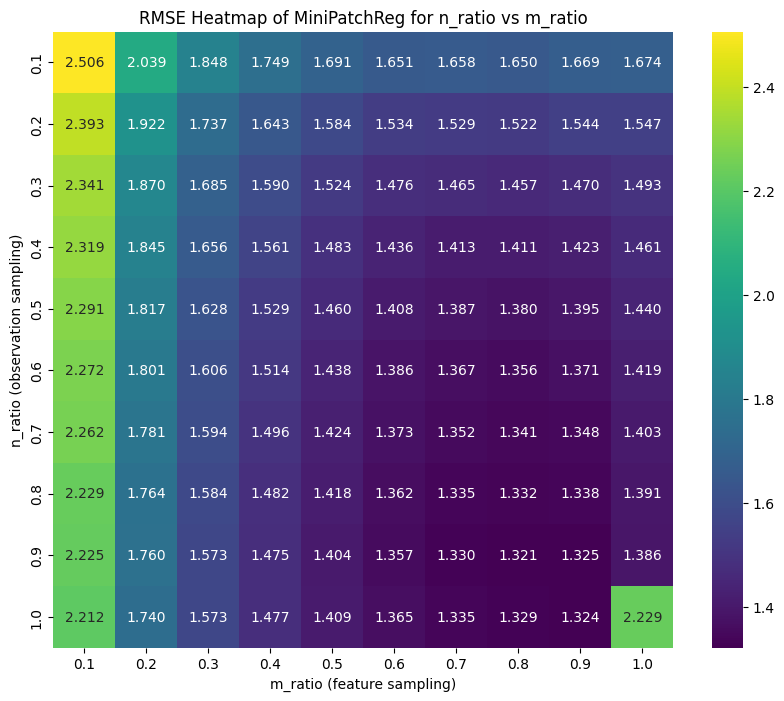

In [8]:
# Parameter grid
n_ratios = np.arange(0.1, 1.1, 0.1)
m_ratios = np.arange(0.1, 1.1, 0.1)

# Flatten the grid into combinations
param_grid = [(i, j, n, m) for i, n in enumerate(n_ratios) for j, m in enumerate(m_ratios)]

# Function to compute RMSE for one combination
def compute_rmse(i, j, n_ratio, m_ratio):
    predictions, _, _ = predictMPReg(X_train, y_train, X_test, n_ratio, m_ratio, B, fit_func)
    mean_pred = np.mean(predictions, axis=0)
    rmse = root_mean_squared_error(y_test, mean_pred)
    return i, j, rmse

# Run in parallel (n_jobs=-1 uses all available cores)
results = Parallel(n_jobs=-1)(delayed(compute_rmse)(i, j, n, m) for i, j, n, m in param_grid)

# Fill the matrix
rmse_matrix = np.zeros((len(n_ratios), len(m_ratios)))
for i, j, rmse in results:
    rmse_matrix[i, j] = rmse

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rmse_matrix, annot=True, fmt=".3f", xticklabels=np.round(m_ratios, 1), yticklabels=np.round(n_ratios, 1), cmap="viridis")
plt.xlabel("m_ratio (feature sampling)")
plt.ylabel("n_ratio (observation sampling)")
plt.title("RMSE Heatmap of MiniPatchReg for n_ratio vs m_ratio")
plt.show()
